In [2]:
import cv2
import matplotlib.pyplot as plt 
from glob import glob 
import numpy as np 


def load_png_object(file_path: str):
    im = cv2.imread(file_path,cv2.IMREAD_UNCHANGED)
    im_dims = im.shape 
    print(f"loaded object: {file_path} with shape: {im_dims}")
    
    return im, im_dims

def load_frame_data(n_frames: int = 1):
    frame_data = glob("frame_data/*.png")
    frames = []
    np_data = []
    for i, f in enumerate(frame_data): 
        frames.append(cv2.imread(f))
        np_file = f.replace(".png",".txt")
        np_data.append(np.loadtxt(np_file))
        if i>=n_frames: 
            return frames, np_data            

    return frames, np_data


        


object_im, object_dims = load_png_object("image_props/hat_rescaled.png")
obj_h, obj_w = object_dims[0], object_dims[1]
obj_centre = (obj_w//2,obj_h//2)

plt.imshow(object_im)   

frames, np_data = load_frame_data(n_frames=2)

[ WARN:0@17.228] global loadsave.cpp:275 findDecoder imread_('image_props/hat_rescaled.png'): can't open/read file: check file path/integrity


AttributeError: 'NoneType' object has no attribute 'shape'

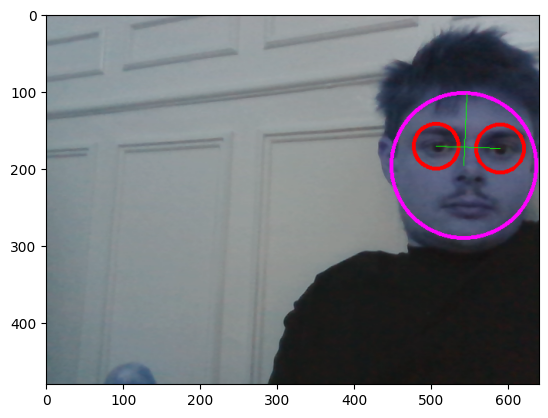

In [2]:
frame = frames[1]
coords = np_data[1]

plt.imshow(frame)

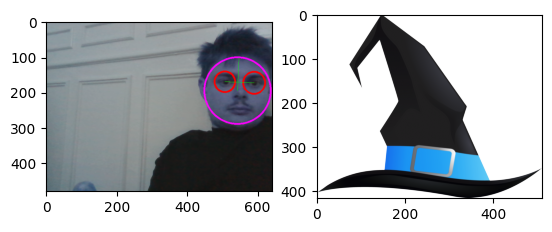

In [3]:
from skimage.transform import rescale
from skimage import io 

frame_dims = frame.shape[0],frame.shape[1]
object_dims = object_im.shape[0], object_im.shape[1]
min_frame_dims = np.min(frame_dims) #always height for webcam type input

width_factor = 0.8*frame_dims[1]/object_dims[1] 
obj_im_rescale = rescale(object_im,width_factor, channel_axis=-1) #currently the image is probably too large 

fix, ax = plt.subplots(1,2)
ax[0].imshow(frame)

ax[1].imshow(obj_im_rescale)

#rescale hat so it is 0.1 of image-width; in principle should be rescaled for face width on the fly later
#object_im = rescale(object_im,)

#io.imsave("hat_rescale.png",obj_im_rescale)


Save smaller version for more efficient compute

In [142]:
obj_im_rescale_uint8 = (obj_im_rescale * 255).astype(np.uint8)
io.imsave("hat_rescaled.png", obj_im_rescale_uint8)


#Make function for blending the two. Only handles negative out of bounds

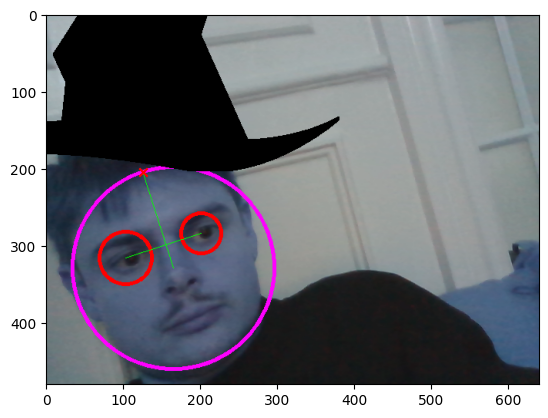

In [ ]:
def insert_hat_on_frame(frame_rgb,obj, coords: tuple[float]):
    #log: fixed so bottom centre is aligned with found face-centre 
    #fixed slicing issues for upper left corner cases 
    #note: not robust to lower/lower right corner cases 
    #TODO: allow slice cropping
    
    frame = frame_rgb.copy()
    im_mask = np.zeros((frame.shape[0],frame.shape[1]))
    hat_mask = obj[:,:,3]>0 #alpha channel: only keep what is actually not transparent
    hat_centre = hat_mask.shape[0]//2, hat_mask.shape[1]//2
    hat_dims = hat_mask.shape[0], hat_mask.shape[1]
    #figure out slices. We just want to place the hat such that the bottom middle pixel aligns with the found coords
    
    slice_start_y = int(coords[1])-hat_dims[0]
    slice_start_x = int(coords[0])-hat_dims[1]//2
    im_mask = np.zeros((frame.shape[0], frame.shape[1]), dtype=bool)
    hat_rgb = obj[:, :, :3]     # discard alpha

    full_hat = np.zeros_like(frame)

    if slice_start_x>0 and slice_start_y>0:  #case: hat is contained in frame 
        im_mask[slice_start_y:slice_start_y+hat_dims[0],slice_start_x:slice_start_x+hat_dims[1]] = hat_mask   
        full_hat[slice_start_y:slice_start_y+hat_dims[0],slice_start_x:slice_start_x+hat_dims[1]] = hat_rgb
        #frame[mask3d] = full_hat[mask3d] 
    elif slice_start_x<0 or slice_start_y<0: #case: upper/left pixels cropped. TODO: make the check formal so we can handle lower-right case as well. 
        lost_pixels_x = np.abs(min([slice_start_x,0]))
        lost_pixels_y = np.abs(min([slice_start_y,0]))
        slice_start_x = max([slice_start_x,0])
        slice_start_y = max([slice_start_y,0])
        im_mask[slice_start_y:slice_start_y+hat_dims[0]-lost_pixels_y,slice_start_x:slice_start_x+hat_dims[1]-lost_pixels_x] = hat_mask[lost_pixels_y:,lost_pixels_x:]
        full_hat[slice_start_y:slice_start_y+hat_dims[0]-lost_pixels_y,slice_start_x:slice_start_x+hat_dims[1]-lost_pixels_x] = hat_rgb[lost_pixels_y:,lost_pixels_x:,:]
    else: #case: need to also slice "outside large boundaries"


    frame[im_mask] = full_hat[im_mask] 

    
    #such that we could handle third case where hat lower/right-region needs to be cropped 
    #elif coords + hat_bounds/2 > im_dims...: 
    
    
    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))
plt.scatter(coords[0],coords[1],marker="x",color="r")



Complete function also handling positive out of bounds

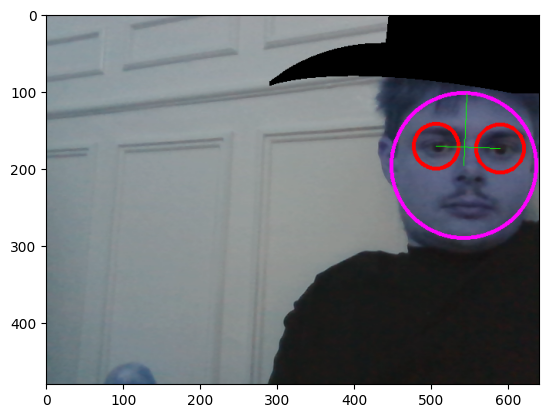

In [4]:
def insert_hat_on_frame(frame_rgb, obj, coords):
    frame = frame_rgb.copy()
    
    Hf, Wf = frame.shape[:2]
    Hh, Wh = obj.shape[:2]

    hat_mask = obj[:, :, 3] > 0
    hat_rgb  = obj[:, :, :3]

    # bottom-center align
    slice_start_y = int(coords[1]) - Hh
    slice_start_x = int(coords[0]) - Wh // 2

    # ---- STEP 1: handle negative starts (crop top/left) ----
    crop_x_left = max(0, -slice_start_x)
    crop_y_top  = max(0, -slice_start_y)

    x1 = max(0, slice_start_x)
    y1 = max(0, slice_start_y)

    # ---- STEP 2: compute end positions BEFORE cropping bottom/right ----
    x2 = x1 + (Wh - crop_x_left)
    y2 = y1 + (Hh - crop_y_top)

    # ---- STEP 3: crop bottom/right if going outside frame ----
    crop_x_right = max(0, x2 - Wf)
    crop_y_bottom = max(0, y2 - Hf)

    # Compute final slice ranges AFTER all cropping
    x2 = x2 - crop_x_right
    y2 = y2 - crop_y_bottom

    # Corresponding crop on hat image
    hat_crop = hat_rgb[crop_y_top:Hh - crop_y_bottom,
                       crop_x_left:Wh - crop_x_right]

    mask_crop = hat_mask[crop_y_top:Hh - crop_y_bottom,
                         crop_x_left:Wh - crop_x_right]

    # ---- STEP 4: insert ----
    im_mask = np.zeros((Hf, Wf), dtype=bool)
    full_hat = np.zeros_like(frame)

    im_mask[y1:y2, x1:x2] = mask_crop
    full_hat[y1:y2, x1:x2] = hat_crop

    frame[im_mask] = full_hat[im_mask]

    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))

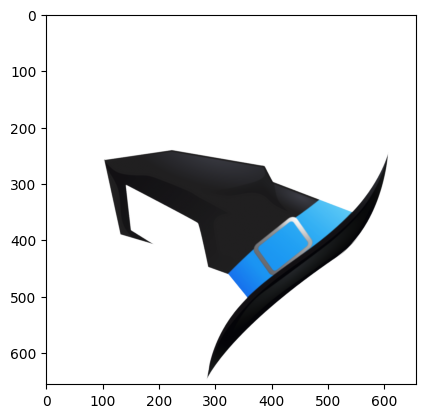

In [ ]:
from skimage.transform import rotate 
# angle in degrees - counter clockwise
rotation_angle = 45

rotation_centre = (obj_im_rescale.shape[0],obj_im_rescale.shape[1]//2)
rotated_img = rotate(obj_im_rescale, rotation_angle,center=rotation_centre,resize=True)
plt.imshow(rotated_img)

In [106]:
obj_im_rescale.shape[0]-77

67

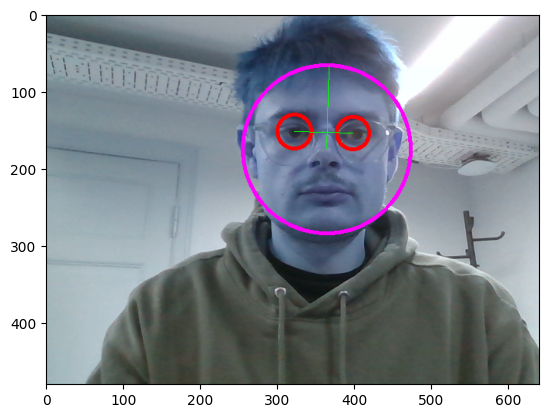

In [65]:
def insert_hat_on_frame(frame, hat_rgba, coords):
    """
    frame: (Hf, Wf, 3) BGR image
    hat_rgba: (Hh, Wh, 4) BGRA image
    coords: (x_center, y_bottom) where the bottom center of the hat should go
    """

    Hf, Wf = frame.shape[:2]
    Hh, Wh = hat_rgba.shape[:2]

    x_center, y_bottom = int(coords[0]), int(coords[1])

    # Compute top-left corner of hat placement
    x1 = x_center - Wh // 2
    y1 = y_bottom - Hh
    x2 = x1 + Wh
    y2 = y1 + Hh

    # Clip if hat goes outside frame
    x1_clip = max(0, x1)
    y1_clip = max(0, y1)
    x2_clip = min(Wf, x2)
    y2_clip = min(Hf, y2)

    if x1_clip >= x2_clip or y1_clip >= y2_clip:
        return frame  # nothing to draw

    # Corresponding coordinates in hat
    hat_x1 = x1_clip - x1
    hat_y1 = y1_clip - y1
    hat_x2 = hat_x1 + (x2_clip - x1_clip)
    hat_y2 = hat_y1 + (y2_clip - y1_clip)

    # Grab region from hat
    hat_region = hat_rgba[hat_y1:hat_y2, hat_x1:hat_x2]

    # Split hat into RGB and alpha
    hat_rgb = hat_region[..., :3].astype(float)
    hat_alpha = (hat_region[..., 3] / 255.0).astype(float)[..., None]  # shape (H,W,1)

    # Grab frame region
    frame_region = frame[y1_clip:y2_clip, x1_clip:x2_clip].astype(float)

    # Blend: out = alpha*hat + (1-alpha)*frame
    out = hat_alpha * hat_rgb + (1 - hat_alpha) * frame_region

    frame[y1_clip:y2_clip, x1_clip:x2_clip] = out.astype(np.uint8)

    return frame

plt.imshow(insert_hat_on_frame(frame,obj_im_rescale,coords))

In [19]:
import numpy as np 

np.random.seed(42)
eye_coords = np.random.randint(low=0,high=10,size=(5,2))
x = eye_coords[:,0]
print(x)
dist_mat = np.abs(x-x[:,None])
left_eye = dist_mat.argmax(axis=0)
print(left_eye)

np.linalg.norm(a[:, None, :] - b[None, :, :], axis=-1)

#faster approach: but don't know if they have scipy installed 
# dists = scipy.spatial.distance.pdist(r, 'cityblock')

[6 7 6 2 7]
[3 3 3 1 3]


NameError: name 'a' is not defined

loaded object: /home/max/Documents/s194119/DTU_research_assistant_work/max/old_prototypes/image_props/hat_rescaled.png with shape: (416, 512, 4)


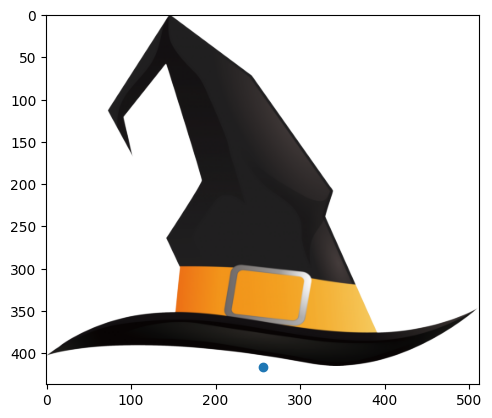

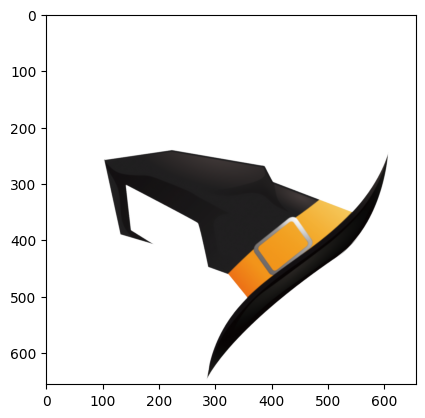

In [18]:
import cv2
import matplotlib.pyplot as plt 
from glob import glob 
import numpy as np 
from skimage.transform import rotate

def load_png_object(file_path: str):
    im = cv2.imread(file_path,cv2.IMREAD_UNCHANGED)
    im_dims = im.shape 
    print(f"loaded object: {file_path} with shape: {im_dims}")
    
    return im, im_dims

def load_frame_data(n_frames: int = 1):
    frame_data = glob("frame_data/*.png")
    frames = []
    np_data = []
    for i, f in enumerate(frame_data): 
        frames.append(cv2.imread(f))
        np_file = f.replace(".png",".txt")
        np_data.append(np.loadtxt(np_file))
        if i>=n_frames: 
            return frames, np_data            

    return frames, np_data


        


object_im, object_dims = load_png_object("/home/max/Documents/s194119/DTU_research_assistant_work/max/old_prototypes/image_props/hat_rescaled.png")
obj_h, obj_w = object_dims[0], object_dims[1]
obj_centre = (obj_w//2,obj_h//2)
plt.figure()
plt.imshow(object_im)   
anchor_point = (object_im.shape[1]//2,object_im.shape[0]) #y, x

plt.scatter(anchor_point[0],anchor_point[1])
frames, np_data = load_frame_data(n_frames=2)

theta = 45
rot_im = rotate(object_im,theta,resize=True, center=(anchor_point[0],anchor_point[1]))
plt.figure()
plt.imshow(rot_im)

theta_rad = np.rad2deg(theta)
rot_mat = np.array([[np.cos(theta_rad),-np.sin(theta_rad)],[np.sin(theta_rad),np.cos(theta_rad)]])



Define vectors

(416, 512, 4)
(656, 656, 4)
126.33552000180907 -169.8059059957103


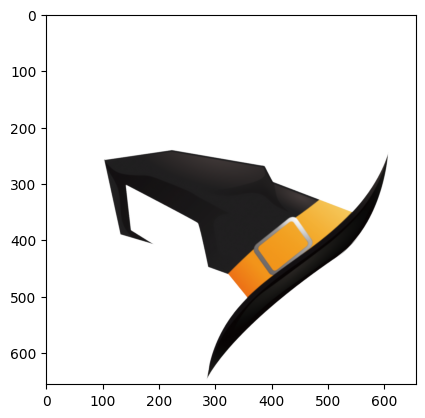

In [34]:
object_im, object_dims = load_png_object("/home/max/Documents/s194119/DTU_research_assistant_work/max/old_prototypes/image_props/hat_rescaled.png")

theta = 45
rot_im = rotate(object_im,theta,resize=True, center=(anchor_point[0],anchor_point[1]))
plt.figure()
plt.imshow(rot_im)

theta_rad = np.rad2deg(theta)
R = np.array([[np.cos(theta_rad),-np.sin(theta_rad)],[np.sin(theta_rad),np.cos(theta_rad)]])


###all definitions in x,y 
OUR = np.array([object_im.shape[1],0])
ODR = np.array([object_im.shape[1],object_im.shape[0]])
ODL = np.array([0,object_im.shape[0]])
OAnchor = np.array([object_im.shape[1]//2,object_im.shape[0]]) #


#calculate size increase of image 
OUR_t = R@OUR #origin to upper right 
ODR_t = R@ODR #origin to lower right 
ODL_t = R@ODL #origin to lower left 
OAnchor_t = R@OAnchor

print(object_im.shape)
print(rot_im.shape)

#now: we just need to know where the zero actually is located. This can in fact be done by calculating the extrema points of the new image based on the corner points of the old image 

if theta>0: 
    dx = np.abs(ODR_t[0])-object_im.shape[1]
    dy = np.abs(ODL_t[1])-object_im.shape[0]
    print(dx,dy)

old shape (rows,cols): (416, 512)
new shape (rows,cols): (657, 657)
anchor new coords (x,y): [181.01933598 475.17575696]
translation (tx,ty): [-74.98066402  59.17575696]


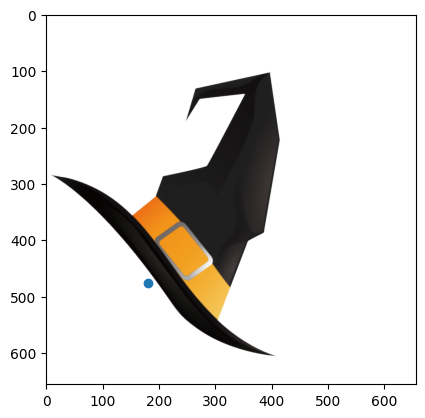

In [41]:
import numpy as np

def rotated_anchor_and_new_shape(image_shape, theta_deg, anchor, center=None):
    """
    image_shape: (rows, cols) from image.shape
    theta_deg: rotation angle in degrees, positive = counterclockwise (math sense)
    anchor: (x, y) as (col, row) coordinates in original image
    center: rotation center as (x, y). If None, center = image center (cols/2, rows/2)
    Returns:
      new_shape: (new_rows, new_cols) as ints
      anchor_new: (x_new, y_new) coordinates of anchor in rotated/resized image (floats)
      translation: (tx, ty) used (i.e. -min_x, -min_y)
      rotated_corner_coords: array shape (4,2) of rotated corners before translation
    """
    rows, cols = image_shape[0], image_shape[1]
    if center is None:
        center = np.array([cols / 2.0, rows / 2.0])  # assume centre rotation 

    # use radians
    theta = np.deg2rad(theta_deg)
    # rotation matrix for image coordinates (x right, y down)
    R = np.array([[np.cos(theta),  np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])

    # corners in (x, y) = (col, row)
    corners = np.array([
        [0.0, 0.0],       # top-left
        [cols, 0.0],      # top-right
        [cols, rows],     # bottom-right
        [0.0, rows]       # bottom-left
    ])

    # rotate corners about center: p' = R (p - c) + c
    rotated = (R @ (corners.T - center.reshape(2,1))).T + center.reshape(1,2)

    # bounding box
    min_x, min_y = rotated[:,0].min(), rotated[:,1].min()
    max_x, max_y = rotated[:,0].max(), rotated[:,1].max()

    new_width = max_x - min_x   # in pixels, float
    new_height = max_y - min_y  # in pixels, float

    # translation applied by resize=True (so that min_x, min_y becomes new origin 0,0)
    translation = np.array([-min_x, -min_y])

    # rotated anchor
    anchor = np.array(anchor, dtype=float)
    anchor_rot = (R @ (anchor - center)) + center  # rotated about center
    anchor_new = anchor_rot + translation

    # return integer new shape in (rows, cols) order
    new_rows = int(np.ceil(new_height))
    new_cols = int(np.ceil(new_width))

    return (new_rows, new_cols), anchor_new, translation, rotated


rows, cols = object_im.shape[0], object_im.shape[1]
anchor = np.array([cols//2, rows])   # note: if you want exact pixel center might be cols/2, rows-1, etc.
center = anchor  # if you rotate about that anchor
theta = -45
rot_im = rotate(object_im,theta,resize=True, center=(anchor_point[0],anchor_point[1]))

new_shape, anchor_new, translation, rotated_corners = rotated_anchor_and_new_shape(
    image_shape=object_im.shape,
    theta_deg=theta,
    anchor=anchor,
    center=center
)

print("old shape (rows,cols):", object_im.shape[:2])
print("new shape (rows,cols):", new_shape)
print("anchor new coords (x,y):", anchor_new)   # x=col, y=row in new image
print("translation (tx,ty):", translation)

plt.imshow(rot_im)
plt.scatter(anchor_new[0],anchor_new[1])

In [44]:
from typing import Tuple 

def rotate_object(object_im: np.ndarray, angle: float, anchor_point: tuple, allow_resize: bool = False) -> Tuple[np.ndarray,np.ndarray,int,int] | Tuple[np.ndarray,np.ndarray]:
    """
    Rotates an image using skimage.transforms.rotate. 
    Finds the corresponding location of the anchor point in the rotated image frame. 
    Returns the difference in image size before and after rotation, dx and dy.  
    
    Args:
        object_im (np.ndarray): the object image to be rotated, (H, W, C)
        angle (float): rotation angle in counter-clockwise direction in degrees. 
        anchor_point (tuple): the centre in object image used rotation. A good idea is to use bottom centre 

    Returns:
        Tuple[np.ndarray,np.ndarray,int,int] 
    """
    h, w = object_im.shape[0], object_im.shape[1]
    object_im = rotate(object_im, angle, center=(anchor_point[1],anchor_point[0]),order=1, resize=allow_resize)
    
    
    #we need to know the anchor point post-translation and resizing. Easiest way is to rotate a mask containing the anchor point with the same transform used for the image 
    anchor_mask = np.zeros((h, w), dtype=np.uint8)
    anchor_mask[anchor_point] = 1
    anchor_rot = rotate(anchor_mask, angle, center=(anchor_point[1],anchor_point[0]), resize=allow_resize, order=0, preserve_range=True)
    #find the new anchor coordinate in the rotated image. This is the coordinate which needs to be mapped to the top centre of head.
    new_anchor = np.argwhere(anchor_rot == 1)[0]   # row, col in rotated space -> y, x 
    
    #calculate the difference in sizes between original image and rotated image. Used for correcting position on top of head if resize is true.
    delta_width = w-object_im.shape[1]
    delta_height = h-object_im.shape[0]
    
    return object_im, new_anchor, delta_width, delta_height 


rot_im_debug, new_anchor, dw, dh = rotate_object(object_im, theta, anchor_point=(0,0),allow_resize=True)

print(new_anchor)


[  0 293]


[181.01933598 475.17575696]


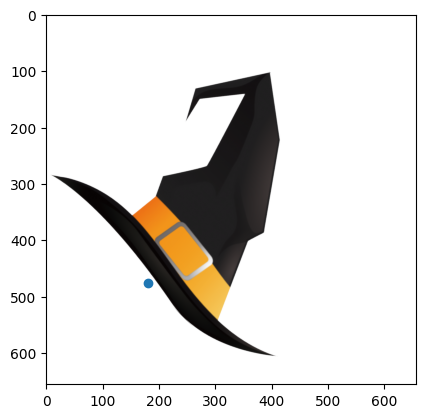

In [50]:
from typing import Tuple 

def rotate_object(object_im: np.ndarray, angle: float, anchor_point: tuple, allow_resize: bool = False) -> Tuple[np.ndarray,np.ndarray,int,int] | Tuple[np.ndarray,np.ndarray]:
    """
    Rotates an image using skimage.transforms.rotate. 
    Finds the corresponding location of the anchor point in the rotated image frame. 
    Returns the difference in image size before and after rotation, dx and dy.  
    
    Args:
        object_im (np.ndarray): the object image to be rotated, (H, W, C)
        angle (float): rotation angle in counter-clockwise direction in degrees. 
        anchor_point (tuple): a key point on object to track through rotation. A good idea is to use bottom centre for hats  

    Returns:
        Tuple[np.ndarray,np.ndarray,int,int] 
    """
    h, w = object_im.shape[0], object_im.shape[1]
    object_im = rotate(object_im, angle, center=(0,0),order=1, resize=allow_resize)

    
    # use radians
    theta = np.deg2rad(angle)
    # rotation matrix for image coordinates (x right, y down)
    R = np.array([[np.cos(theta),  np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])

    # corners in (x, y) = (col, row)
    corners = np.array([
        [0.0, 0.0],       # top-left
        [w, 0.0],      # top-right
        [w, h],     # bottom-right
        [0.0, h]       # bottom-left
    ])

    # rotate corners about center: p' = R (p - c) + c
    rotated = (R @ (corners.T)).T

    # bounding box
    min_x, min_y = rotated[:,0].min(), rotated[:,1].min()
    max_x, max_y = rotated[:,0].max(), rotated[:,1].max()

    new_width = max_x - min_x   # in pixels, float
    new_height = max_y - min_y  # in pixels, float

    # translation applied by resize=True (so that min_x, min_y becomes new origin 0,0)
    translation = np.array([-min_x, -min_y])

    # rotated anchor
    anchor = anchor_point.astype(float)
    anchor_rot = (R @ (anchor))  # rotated about center
    anchor_new = anchor_rot + translation

    # return integer new shape in (rows, cols) order
    new_rows = int(np.ceil(new_height))
    new_cols = int(np.ceil(new_width))


    return object_im, anchor_new 
    #return (new_rows, new_cols), anchor_new, translation, rotated

    
    
    # #we need to know the anchor point post-translation and resizing. Easiest way is to rotate a mask containing the anchor point with the same transform used for the image 
    # anchor_mask = np.zeros((h, w), dtype=np.uint8)
    # anchor_mask[anchor_point] = 1
    # anchor_rot = rotate(anchor_mask, angle, center=(anchor_point[1],anchor_point[0]), resize=allow_resize, order=0, preserve_range=True)
    # #find the new anchor coordinate in the rotated image. This is the coordinate which needs to be mapped to the top centre of head.
    # new_anchor = np.argwhere(anchor_rot == 1)[0]   # row, col in rotated space -> y, x 
    
    # #calculate the difference in sizes between original image and rotated image. Used for correcting position on top of head if resize is true.
    # delta_width = w-object_im.shape[1]
    # delta_height = h-object_im.shape[0]
    
    # return object_im, new_anchor, delta_width, delta_height 


OAnchor = np.array([object_im.shape[1]//2,object_im.shape[0]]) #
theta = -45
rot_im_debug, new_anchor = rotate_object(object_im, theta, anchor_point=OAnchor,allow_resize=True)

print(new_anchor)

plt.imshow(rot_im_debug)
plt.scatter(new_anchor[0],new_anchor[1])


[452.82424304 302.86291501]


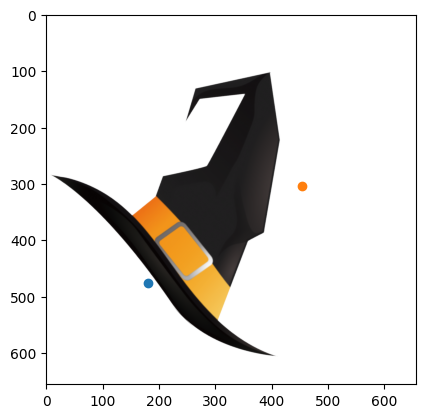

In [51]:
from skimage.transform import rotate, AffineTransform
import numpy as np

def rotate_with_anchor(obj, theta, anchor, allow_resize=True):
    H, W = obj.shape[:2]
    cx, cy = anchor

    # compute skimage transform (same as rotate uses)
    theta_rad = np.deg2rad(theta)
    R = AffineTransform(rotation=theta_rad, 
                        translation=(0,0))  # temporary

    # rotation about anchor → translate, rotate, translate back
    T = AffineTransform(translation=(-cx, -cy))
    R = T + R + AffineTransform(translation=(cx, cy))

    # find all corners to compute bounding box (skimage does this internally)
    corners = np.array([
        [0,0], [W,0], [W,H], [0,H]
    ], dtype=float)

    corners_rot = R(corners)

    min_x = corners_rot[:,0].min()
    min_y = corners_rot[:,1].min()

    # translation skimage applies when resize=True
    T_resize = (-min_x, -min_y)

    # final transform skimage uses:
    R_final = AffineTransform(translation=T_resize) + R

    # get anchor in rotated+resized image
    anchor_new = R_final(np.array([[cx, cy]]) )[0]

    # perform rotation
    obj_rot = rotate(obj, theta, center=(cx, cy), resize=allow_resize, preserve_range=True)

    return obj_rot.astype(obj.dtype), anchor_new

object_im_trf, new_anchor_point = rotate_with_anchor(object_im, theta, anchor_point, allow_resize=True)

print(new_anchor_point)

plt.imshow(rot_im_debug)
plt.scatter(new_anchor[0],new_anchor[1])
plt.scatter(new_anchor_point[0],new_anchor_point[1])

